# MLPs for classification on the MNIST dataset

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Nov 26, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Nov 29, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Improvements to code and comments |


## 1. Details on the dataset

We are using the **MNIST database** (Modified National Institute of Standards and Technology database).

It consists of 60,000 training images and 10,000 testing images. Each image is a $28 \times 28$ grayscale grid representing a digit from 0 to 9.

![Sample images from the MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

More information about this dataset is available at:

https://en.wikipedia.org/wiki/MNIST_database



## 2. Setup and Imports

Let's begin by importing the necessary libraries and setting up our computation device (GPU if available, otherwise CPU).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Check for device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data preparation and preprocessing

The raw MNIST data comes with pixel values in the range $[0, 1]$. However, neural networks often converge faster and more stably when input features are centered around zero.

We will normalize our dataset to be in the range $[-1, 1]$.
  * **Transformation:** We use `transforms.Normalize((0.5,), (0.5,))`.
  * **Math:** given a pixel $x \in [0, 1]$, the output is $(x - 0.5)/0.5$.

In [2]:
# Define the transformation: Convert to Tensor and Normalize to [-1, 1]
transform = transforms.Compose([
    # Convert a Image in the range [0, 255] to a torch.FloatTensor in the range [0.0, 1.0]
    transforms.ToTensor(),

    # torchvision.transforms.Normalize(mean, std, inplace=False)
    # Normalize a tensor image with mean 0.5 and standard deviation 0.5
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=1000,       shuffle=False)

print()
print(f"Training test: {len(train_dataset):6d} samples")
print(f"Testing set:   {len(test_dataset) :6d} samples")


Training test:  60000 samples
Testing set:    10000 samples


## 3. Defining the Architecture

We will build an MLP with the following  design choices:

1.  **Input:** 784 units (flattened $28 \times 28$ image).
2.  **Hidden Layers:** We will use two hidden layers with ReLU activation.
3.  **Biases:** Enabled by default in `nn.Linear`.
4.  **Weight Initialization:** We will use **Xavier (Glorot) Initialization**. This keeps the scale of the gradients roughly the same in all layers, preventing vanishing or exploding gradients.
5.  **Output:** 10 units (one for each digit).

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10):
        super(MLP, self).__init__()

        # Define layers
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(input_size,     hidden_size,    bias=True)
        self.layer2 = nn.Linear(hidden_size,    hidden_size//2, bias=True)
        self.layer3 = nn.Linear(hidden_size//2, num_classes,    bias=True)

        # Apply Weight Initialization
        self._init_weights()

    def _init_weights(self):
        # Using Xavier Uniform Initialization for better convergence
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Flatten the image input
        x = x.view(-1, 28*28)

        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        # We output logits here.
        # The Softmax is implicitly calculated during CrossEntropyLoss training,
        # or explicitly applied during inference.
        logits = self.layer3(x)
        return logits

## 4. The training framework

We need a robust training loop. We will implement **L2 Regularization** to prevent overfitting. In PyTorch, this is done via the `weight_decay` parameter in the optimizer.

We will also track the **Norm of the Gradient**. This is a crucial diagnostic tool. If the norm is too small, the network isn't learning (vanishing gradient); if it's too high, the training might be unstable.

### Mathematical Context

The Loss function we use is **Cross Entropy**, defined as:

$$H(p, q) = -\sum_{x} p(x) \log q(x)$$

Where $p(x)$ is the true distribution (one-hot encoded label) and $q(x)$ is our predicted probability (output of Softmax).

In [4]:
def train_model(model, train_loader, optimizer, scheduler, num_epochs=10):
    model.train()
    loss_fn = nn.CrossEntropyLoss()

    # Lists to store metrics for plotting
    epoch_losses = []

    print(f"{'Epoch':<10} | {'Loss':^15} | {'Grad Norm':^15} | {'LR':^15}")
    print("-" * 65)

    for epoch in range(1, num_epochs+1):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 1. Forward pass
            outputs = model(images)
            loss    = loss_fn(outputs, labels)

            # 2. Backward pass
            optimizer.zero_grad()
            loss.backward()

            # 3. Calculate Gradient Norm (for reporting)
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5

            # 4. Update weights
            optimizer.step()

            running_loss += loss.item()

        # Step the scheduler
        if scheduler:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = optimizer.param_groups[0]['lr']

        avg_loss = running_loss/len(train_loader)
        epoch_losses.append(avg_loss)

        # Report every epoch
        print(f"{epoch:>10d} | {avg_loss:15.5f} | {total_norm:15.5f} | {current_lr:15.5f}")

    return epoch_losses

## 5\. Experiment: Exploring Schedulers

We will run two experiments to see how the learning rate schedule affects convergence.

1.  **Constant Learning Rate:** A standard approach.
2.  **StepLR:** Decays the learning rate by a factor $\gamma$ every `step_size`epochs. See [documentation](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html).

We will use **Stochastic Gradient Descent (SGD)** with L2 Regularization (`weight_decay=1e-4`).

In [5]:
%%time

# Experiment 1: Step LR Scheduler
print("\n--- Training with StepLR Scheduler ---")
model_step = MLP().to(device)
optimizer_step = optim.SGD(model_step.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_step = optim.lr_scheduler.StepLR(optimizer_step, step_size=5, gamma=0.1)

losses_step = train_model(model_step, train_loader, optimizer_step, scheduler_step, num_epochs=20)


--- Training with StepLR Scheduler ---
Epoch      |      Loss       |    Grad Norm    |       LR       
-----------------------------------------------------------------
         1 |         0.31192 |         1.68840 |         0.01000
         2 |         0.14016 |         1.53276 |         0.01000
         3 |         0.10114 |         1.29174 |         0.01000
         4 |         0.08305 |         2.44908 |         0.01000
         5 |         0.06841 |         1.06146 |         0.00100
         6 |         0.03774 |         0.72292 |         0.00100
         7 |         0.03331 |         0.45704 |         0.00100
         8 |         0.03179 |         2.80247 |         0.00100
         9 |         0.03044 |         2.69894 |         0.00100
        10 |         0.02926 |         0.81675 |         0.00010
        11 |         0.02706 |         0.07015 |         0.00010
        12 |         0.02675 |         2.43793 |         0.00010
        13 |         0.02657 |         0.53419 | 

In [6]:
%%time

# Experiment 2: Constant LR (No Scheduler)
print("\n--- Training with Constant LR ---")
model_const = MLP().to(device)
optimizer_const = optim.SGD(model_const.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_step = None # No Scheduler

losses_const = train_model(model_const, train_loader, optimizer_const, scheduler_step, num_epochs=20)


--- Training with Constant LR ---
Epoch      |      Loss       |    Grad Norm    |       LR       
-----------------------------------------------------------------
         1 |         0.30951 |         0.86982 |         0.01000
         2 |         0.14338 |         2.23666 |         0.01000
         3 |         0.10689 |         2.80877 |         0.01000
         4 |         0.08504 |         2.53070 |         0.01000
         5 |         0.06888 |         0.90943 |         0.01000
         6 |         0.05816 |         1.28059 |         0.01000
         7 |         0.04855 |         1.31533 |         0.01000
         8 |         0.04293 |         0.41065 |         0.01000
         9 |         0.03668 |         2.43174 |         0.01000
        10 |         0.03177 |         0.86316 |         0.01000
        11 |         0.02909 |         1.23775 |         0.01000
        12 |         0.02280 |         2.56591 |         0.01000
        13 |         0.02205 |         1.03994 |      

## 6\. Visualization: Learning Curves

Visualizing the loss is vital. We will plot the Y-axis on a **logarithmic scale** to better visualize the convergence behavior when the loss values become small.

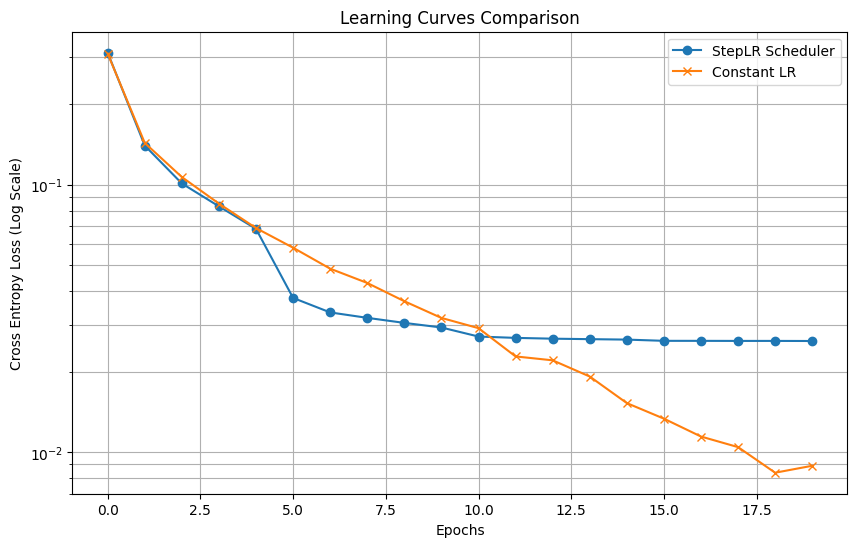

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(losses_step,  label='StepLR Scheduler', marker='o')
plt.plot(losses_const, label='Constant LR',      marker='x')
plt.yscale('log') # Log scale
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss (Log Scale)')
plt.title('Learning Curves Comparison')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

## 7\. Evaluation and Error Analysis

Now, let's estimate the **Test Error** and visualize the results using the `model_step` (the one with the scheduler).

We will create a function that not only calculates accuracy but also gathers examples of images the model got right and images it got wrong.

In [8]:
def evaluate_and_visualize(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    # Store samples for visualization
    misclassified_samples   = []
    well_classified_samples = []

    softmax = nn.Softmax(dim=1) # Explicit Softmax for probability interpretation

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Apply Softmax to get probabilities
            probs = softmax(outputs)

            # Get top 3 probabilities and their indices
            topk_values, topk_indices = torch.topk(probs, 3, dim=1)

            # Get the predicted class (index of max probability)
            _, predicted = torch.max(probs.data, 1)

            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Collect samples
            mask_incorrect = predicted != labels
            mask_correct   = predicted == labels

            if len(misclassified_samples) < 10:
                # Store: image, predicted_label, true_label, top3_values, top3_indices
                for i in range(len(labels)):
                    if mask_incorrect[i] and len(misclassified_samples) < 10:
                        misclassified_samples.append((images[i], predicted[i], labels[i], topk_values[i], topk_indices[i]))

            if len(well_classified_samples) < 10:
                for i in range(len(labels)):
                    if mask_correct[i] and len(well_classified_samples) < 10:
                        well_classified_samples.append((images[i], predicted[i], labels[i], topk_values[i], topk_indices[i]))

    test_accuracy = 100*correct/total
    test_error    = 100 - test_accuracy

    print(f"Accuracy on test set: {test_accuracy:6.2f}%")
    print(f"Test error:           {test_error   :6.2f}%")

    return well_classified_samples, misclassified_samples

# Run evaluation
good_samples, bad_samples = evaluate_and_visualize(model_step, test_loader)

Accuracy on test set:  97.92%
Test error:             2.08%


### Visualizing Predictions

Finally, let's look at the actual images. This "qualitative" analysis is just as important as the quantitative metrics.

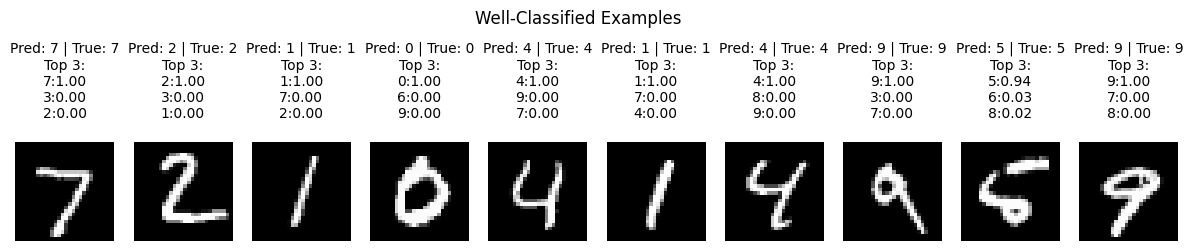

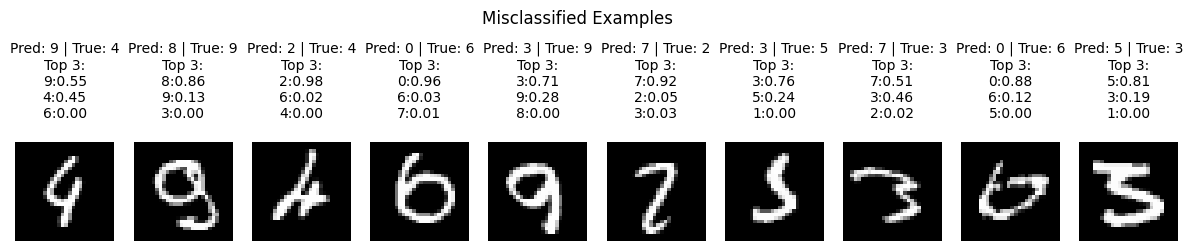

In [9]:
def plot_samples(samples, title):
    fig, axes = plt.subplots(1, 10, figsize=(15, 4))
    fig.suptitle(title, y=0.95)

    for i, (img, pred, true, top3_values, top3_indices) in enumerate(samples):
        # Denormalize image for viewing: 0.5*x + 0.5
        img = img.cpu().numpy().transpose(1, 2, 0)
        img = 0.5*img + 0.5

        axes[i].imshow(img.squeeze(), cmap='gray')

        # Format top 3 predictions
        top3_str = ""
        for j in range(3):
            top3_str += f"{top3_indices[j].item()}:{top3_values[j].item():.2f}\n"
        axes[i].set_title(f"Pred: {pred.item()} | True: {true.item()}\n"
                          f"Top 3:\n"
                          f"{top3_str}", fontsize=10)
        axes[i].axis('off')
    plt.show()

plot_samples(good_samples, "Well-Classified Examples")
plot_samples(bad_samples,  "Misclassified Examples")

Notice the misclassified examples above. Often, these digits are sloppily written or ambiguous even to human eyes. This is where the remaining error usually lies.

## 8. Calculation of the confusion matrix
 The **confusion matrix** is a powerful tool for evaluating the performance of a classification model. Here, the rows represent the true labels and the columns represent the predicted labels. The numbers in each cell indicate how many times a digit from the true label (row) was predicted as the corresponding predicted label (column).

Ideally, the highest numbers should be along the diagonal, indicating that the model correctly predicted the digit. For example, the cell at (0,0) shows how many times a '0' was correctly identified as a '0'. Off-diagonal values indicate misclassifications. For instance, a number in cell (4,9) would mean that an image that was actually a '4' was predicted as a '9'. This visualization helps us quickly identify which digits the model struggles to differentiate.

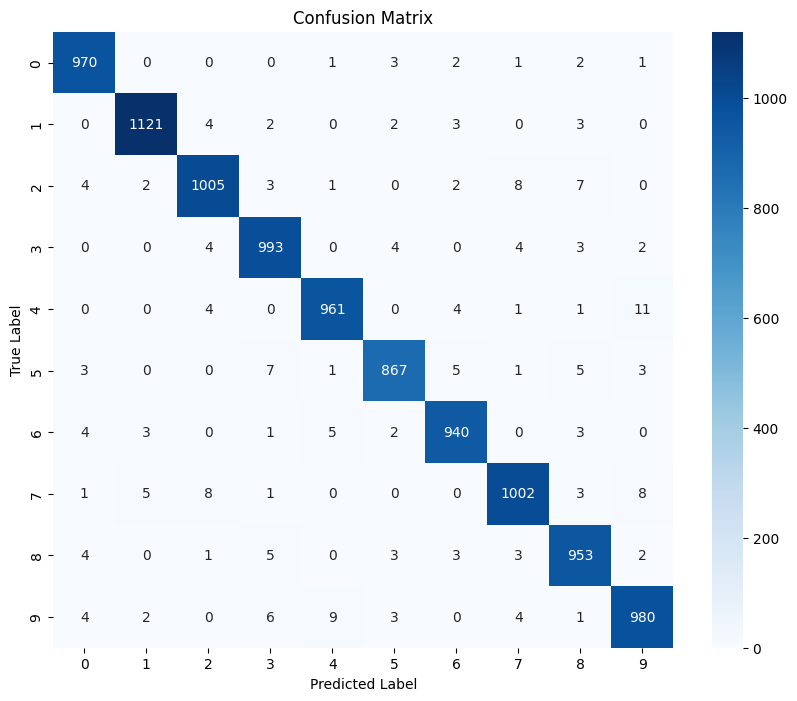

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Ensure the model is in evaluation mode
model_step.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_step(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()